118 images × 39209 neurons


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done  50 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done  65 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done  80 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 133 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done 152 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 173 tasks      | elapsed:    4.4s
[Parallel(n_jobs=-1)]: Done 194 tasks      | elapsed:    4.8s
[Parallel(n_jobs=-1)]: Done 217 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 240 tasks      | elapsed:  

Top 10 neurons by CV R^2:
n= 1762  beta=+0.4274  R2cv=0.1594±0.1354  alpha=1.00e+01
n=36589  beta=+0.3336  R2cv=0.1232±0.1340  alpha=1.00e+01
n= 7230  beta=-0.3124  R2cv=0.0808±0.1267  alpha=2.15e+01
n=19556  beta=+0.2605  R2cv=0.0716±0.1293  alpha=4.64e+01
n=17797  beta=+0.2715  R2cv=0.0669±0.0853  alpha=2.15e+01
n=24055  beta=-0.2733  R2cv=0.0666±0.2155  alpha=2.15e+01
n=23916  beta=+0.3531  R2cv=0.0600±0.2092  alpha=2.15e+01
n=26996  beta=+0.2545  R2cv=0.0596±0.1396  alpha=2.15e+00
n= 4200  beta=+0.2898  R2cv=0.0578±0.1382  alpha=2.15e+01
n=35775  beta=+0.2677  R2cv=0.0556±0.1223  alpha=2.15e+01


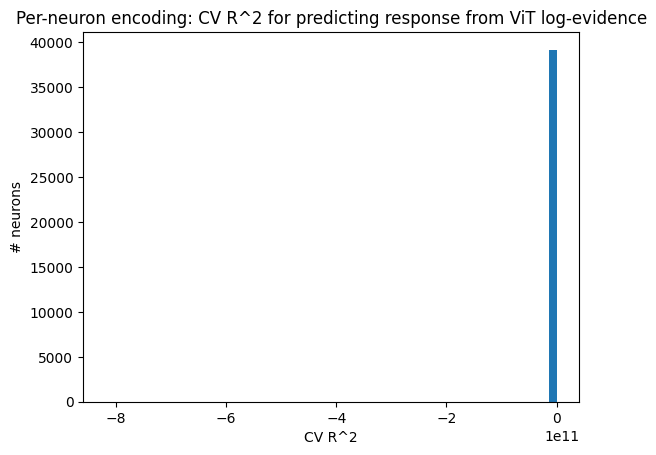

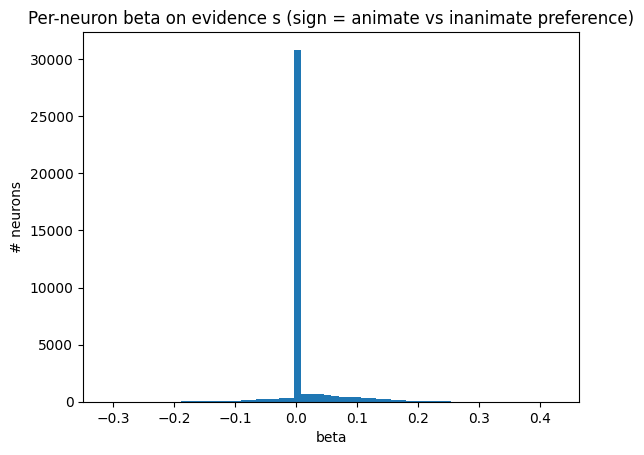

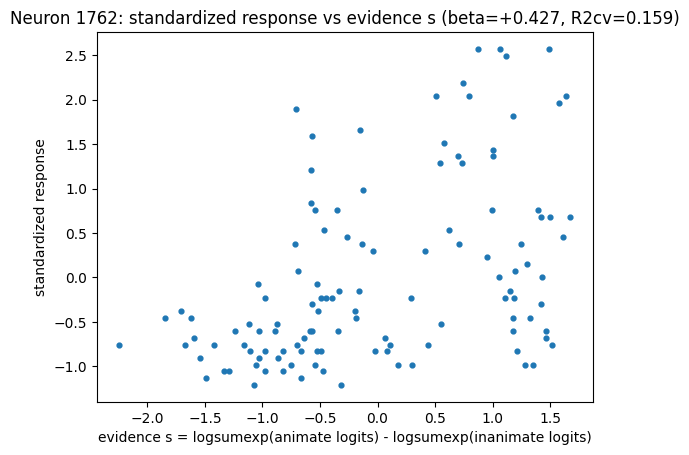

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold
from scipy.special import logsumexp

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
AREAS_PATH  = '/home/maria/ProjectionSort/data/brain_area.npy'

# ============================================================
# LOAD DATA
# ============================================================

vit   = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000) logits
R     = np.load(NEURAL_PATH).T                                   # (images, neurons)
areas = np.load(AREAS_PATH, allow_pickle=True)

n_images, n_neurons = R.shape
print(f"{n_images} images × {n_neurons} neurons")

# ============================================================
# LOG-EVIDENCE TARGET FROM VIT LOGITS
# ============================================================

ANIMATE_MAX = 397  # inclusive
anim_idx = np.arange(0, ANIMATE_MAX + 1)
inan_idx = np.arange(ANIMATE_MAX + 1, vit.shape[1])

# log evidence ratio: log sum exp over animate - log sum exp over inanimate
s = logsumexp(vit[:, anim_idx], axis=1) - logsumexp(vit[:, inan_idx], axis=1)  # (images,)

# optional: center/scale the target (makes ridge numerically nicer; doesn't change significance tests)
s = (s - s.mean()) / (s.std() + 1e-12)

# ============================================================
# ENCODING REGRESSION PER NEURON: r_n ~ s
# ============================================================

# We'll do ridge regression with CV per neuron:
# r_n = alpha + beta*s + noise
# (This is an "encoding" model: does neuron track animacy evidence?)

alphas = np.logspace(-4, 4, 25)
cv = KFold(n_splits=10, shuffle=True, random_state=0)

def fit_one_neuron(n: int):
    y_n = R[:, n].astype(np.float64)

    # standardize the neuron's response across images (recommended)
    y_n = (y_n - y_n.mean()) / (y_n.std() + 1e-12)

    # design matrix with intercept + s
    X = np.c_[np.ones_like(s), s]

    # RidgeCV expects features; we will NOT penalize intercept by centering:
    # easiest is to fit with fit_intercept=False since we included ones column.
    model = RidgeCV(alphas=alphas, cv=cv, fit_intercept=False)
    model.fit(X, y_n)

    yhat = model.predict(X)

    # cross-val R^2 estimate (simple manual CV so we can report it)
    r2_folds = []
    for tr, te in cv.split(X):
        m = RidgeCV(alphas=[model.alpha_], cv=None, fit_intercept=False)
        m.fit(X[tr], y_n[tr])
        pred = m.predict(X[te])
        ss_res = np.sum((y_n[te] - pred) ** 2)
        ss_tot = np.sum((y_n[te] - y_n[te].mean()) ** 2) + 1e-12
        r2_folds.append(1 - ss_res / ss_tot)

    coef_intercept, coef_s = model.coef_[0], model.coef_[1]
    return {
        "neuron": n,
        "alpha": model.alpha_,
        "beta": coef_s,
        "r2_cv_mean": float(np.mean(r2_folds)),
        "r2_cv_std": float(np.std(r2_folds)),
    }

results = Parallel(n_jobs=-1, verbose=10)(
    delayed(fit_one_neuron)(n) for n in range(n_neurons)
)

# ============================================================
# QUICK SUMMARIES / PLOTS
# ============================================================

betas = np.array([d["beta"] for d in results])
r2s   = np.array([d["r2_cv_mean"] for d in results])

print("Top 10 neurons by CV R^2:")
top = np.argsort(-r2s)[:10]
for i in top:
    d = results[i]
    print(f"n={d['neuron']:5d}  beta={d['beta']:+.4f}  R2cv={d['r2_cv_mean']:.4f}±{d['r2_cv_std']:.4f}  alpha={d['alpha']:.2e}")

plt.figure()
plt.hist(r2s, bins=60)
plt.title("Per-neuron encoding: CV R^2 for predicting response from ViT log-evidence")
plt.xlabel("CV R^2")
plt.ylabel("# neurons")
plt.show()

plt.figure()
plt.hist(betas, bins=60)
plt.title("Per-neuron beta on evidence s (sign = animate vs inanimate preference)")
plt.xlabel("beta")
plt.ylabel("# neurons")
plt.show()

# Optional: inspect one neuron fit visually
idx = int(top[0])
n0 = results[idx]["neuron"]
plt.figure()
plt.scatter(s, (R[:, n0] - R[:, n0].mean())/(R[:, n0].std()+1e-12), s=12)
plt.title(f"Neuron {n0}: standardized response vs evidence s (beta={results[idx]['beta']:+.3f}, R2cv={results[idx]['r2_cv_mean']:.3f})")
plt.xlabel("evidence s = logsumexp(animate logits) - logsumexp(inanimate logits)")
plt.ylabel("standardized response")
plt.show()

In [2]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from scipy.stats import pearsonr

# R: (n_images, n_neurons)
# s: (n_images,)  (already log-evidence; you can standardize it or not)

# (optional but recommended) standardize target
s_z = (s - s.mean()) / (s.std() + 1e-12)

outer = KFold(n_splits=10, shuffle=True, random_state=0)
inner = KFold(n_splits=5, shuffle=True, random_state=1)

alphas = np.logspace(-6, 6, 35)

s_hat = np.empty_like(s_z)
chosen_alpha = []

for tr, te in outer.split(R):
    Xtr, Xte = R[tr], R[te]
    ytr = s_z[tr]

    # scale features using only training data
    scaler = StandardScaler(with_mean=True, with_std=True)
    Xtr_s = scaler.fit_transform(Xtr)
    Xte_s = scaler.transform(Xte)

    # --- inner CV to pick alpha on training set ---
    best_a, best_mse = None, np.inf
    for a in alphas:
        mses = []
        for tr2, va2 in inner.split(Xtr_s):
            model = Ridge(alpha=a, fit_intercept=True, random_state=0)
            model.fit(Xtr_s[tr2], ytr[tr2])
            pred = model.predict(Xtr_s[va2])
            mses.append(np.mean((ytr[va2] - pred) ** 2))
        mse = float(np.mean(mses))
        if mse < best_mse:
            best_mse, best_a = mse, a

    chosen_alpha.append(best_a)

    # --- fit final model with chosen alpha, predict held-out ---
    model = Ridge(alpha=best_a, fit_intercept=True, random_state=0)
    model.fit(Xtr_s, ytr)
    s_hat[te] = model.predict(Xte_s)

# --- decoding metrics on held-out predictions ---
mse = np.mean((s_z - s_hat) ** 2)
ss_tot = np.sum((s_z - s_z.mean()) ** 2) + 1e-12
ss_res = np.sum((s_z - s_hat) ** 2)
r2 = 1 - ss_res / ss_tot

r, p = pearsonr(s_z, s_hat)

print(f"[Population decode] outer-CV: R2={r2:.4f}, MSE={mse:.4f}, Pearson r={r:.4f} (p={p:.2e})")
print(f"[Population decode] median chosen alpha = {np.median(chosen_alpha):.3g}")

[Population decode] outer-CV: R2=0.2630, MSE=0.7370, Pearson r=0.5285 (p=7.71e-10)
[Population decode] median chosen alpha = 1e-06
